In [2]:
"""!pip install pandas numpy opencv-python matplotlib scikit-learn mediapipe json"""

'!pip install pandas numpy opencv-python matplotlib scikit-learn mediapipe json'

<h1> Tiền xử lí dữ liệu

In [1]:
# Import thư viện
import os
import pandas as pd
import numpy as np
import cv2
from matplotlib import pyplot as plt
import mediapipe as mp
from sklearn.model_selection import train_test_split

# Định nghĩa đường dẫn dữ liệu
RAW_DATA_DIR = "../data/raw/"
PROCESSED_DATA_DIR = "../data/processed/"

In [3]:

def euclidean_distance(v1, v2):
    return np.sqrt((float(v1[0]) - float(v2[0])) ** 2 + (float(v1[1]) - float(v2[1])) ** 2)


# Trích xuất keyframes

## Khai báo các hàm 

<h3> Hàm đọc video từ đường dẫn 

In [96]:
# Đọc video từ đường dẫn
def ReadVideo(video_path):    
    # Read the input video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video file {video_path}")
    return cap

<h3> Hàm chuyển tất cả khung hình sang xám

In [97]:
# Hàm chuyển tất cả khung hình lấy được sang khung hình xám
def getGrayFramesAndFrames(cap):
    frames = []
    gray_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frames.append(frame)        
        # Chuyển frame sang gray
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_frames.append(gray_frame)
    
    # giải phóng đối tượng cap
    cap.release()
    return gray_frames, frames

<h3> Hàm tính độ khác biệt giữa mỗi 2 frame liên tiếp

In [98]:
def calculate_histogram_differences(gray_frames):
    HDiffs = []
    # Duyệt qua tất cả các frame trừ frame cuối vì thường là frame không có giá trị
    for i in range(0, len(gray_frames)-1):
        if (i == 0):
        #[gray_frames[i]]: grayframe thứ i, [0] kênh chứa độ sáng, None: tính toàn bộ ảnh, không dùng mask, [256]: 256 bins, 0 <=[0, 256]: giá trị pixel < 256
            hist_curr = cv2.calcHist([gray_frames[i]], [0], None, [256], [0, 256])
            continue
        # Gán frame ở vòng lặp trước cho hist_prev và tính lại hist_curr
        hist_prev = hist_curr
        hist_curr = cv2.calcHist([gray_frames[i]], [0], None, [256], [0, 256])

        Hdiff = np.sum(np.abs(hist_prev - hist_curr))
        HDiffs.append(Hdiff)
    return HDiffs

<h3> Hàm trích xuất keyframes

In [99]:
def Extract_key_frames(video_path):
    cap = ReadVideo(video_path)
    gray_frames, frames = getGrayFramesAndFrames(cap)
    HDiffs = calculate_histogram_differences(gray_frames)
    mean = np.mean(HDiffs)
    std = np.std(HDiffs)
    threshold = mean + std
    # Chọn keyframes dựa trên ngưỡng
    keyframes = []
    for i in range(len(HDiffs)):
        if HDiffs[i] > threshold:
            # Lấy frame i+1 vì Hdiffs[i] là độ khác biệt của frame thứ i +1 với thứ i
            keyframes.append(frames[i+1])
    return keyframes

## Kiểm thử

<h3> Thiết lập đường dẫn

In [100]:
#namevideo ="00668"
# namevideo ="17960"
namevideo = "00891"
video_path = rf'D:\Study_space\Ki6\sign_language_recognition_project\Sign_Language_Recognition\data\raw\videos\{namevideo}.mp4' 

<h3> Chuyển tất cả frame sang gray

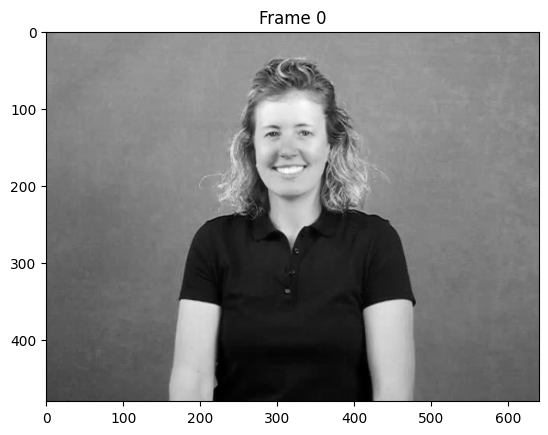

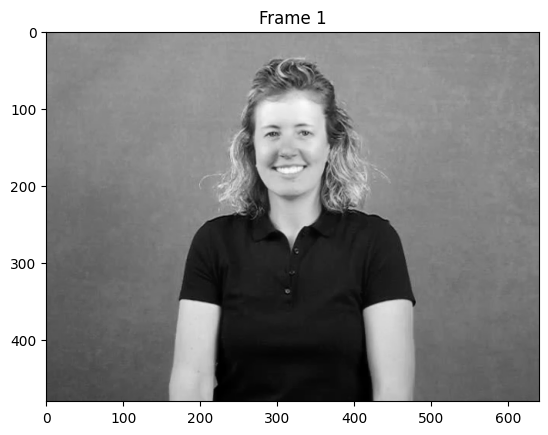

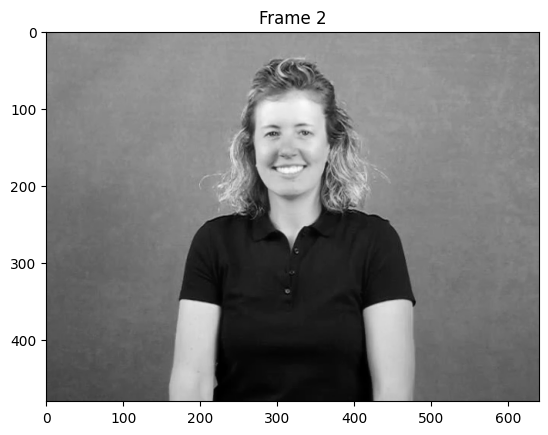

In [101]:
cap = ReadVideo(video_path)
gray_frames, frames = getGrayFramesAndFrames(cap)

# Hiển thị các frame để kiểm tra
for i, gray_frame in enumerate(gray_frames):
    plt.imshow(cv2.cvtColor(gray_frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {i}")
    plt.show()
    if i > 1:
        break

if len(gray_frames) <= 1:
    print("Not enough frames could be extracted from the video")

Number of keyframes: 32


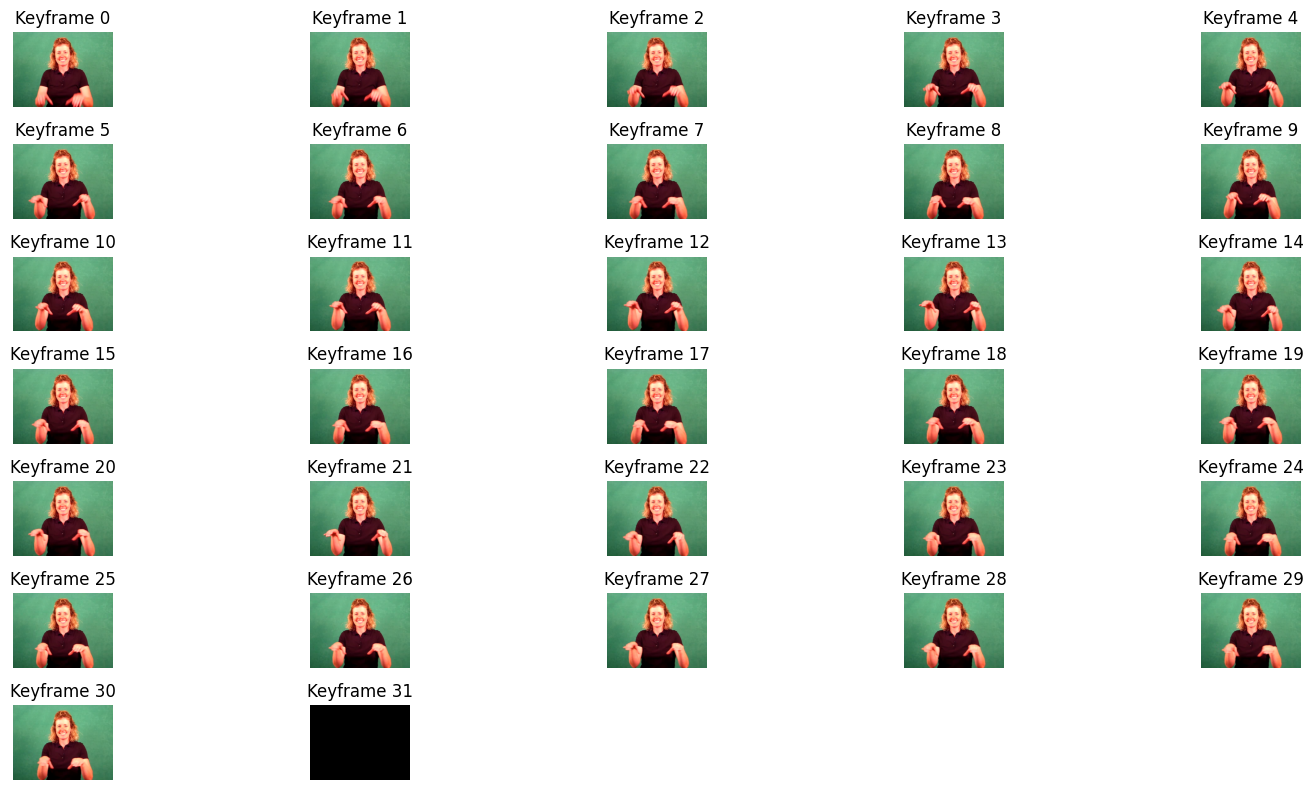

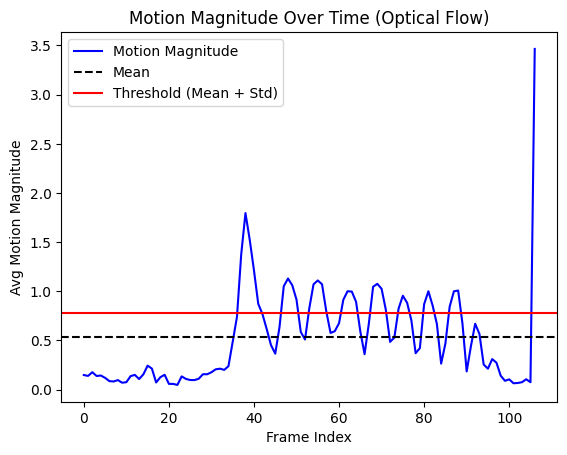

In [ ]:
# def read_video(video_path):
#     cap = cv2.VideoCapture(video_path)
#     frames = []
#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break
#         frames.append(frame)
#     cap.release()
#     return frames

# def compute_motion_magnitudes(frames):
#     magnitudes = []
#     prev_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
    
#     for i in range(1, len(frames)):
#         curr_gray = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)

#         # Farneback Optical Flow
#         flow = cv2.calcOpticalFlowFarneback(prev_gray, curr_gray, None,
#                                             pyr_scale=0.5, levels=3, winsize=15,
#                                             iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
        
#         mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
#         avg_mag = np.mean(mag)
#         magnitudes.append(avg_mag)

#         prev_gray = curr_gray
    
#     return magnitudes

# def extract_keyframes(frames, magnitudes, threshold_factor=0.5):
#     mean = np.mean(magnitudes)
#     std = np.std(magnitudes)
#     threshold = mean + threshold_factor * std
    
#     keyframes = []
#     for i in range(len(magnitudes)):
#         if magnitudes[i] > threshold:
#             keyframes.append(frames[i + 1])  # vì magnitudes[i] là sự khác biệt giữa i+1 và i
    
#     return keyframes, mean, threshold

# def plot_motion(magnitudes, mean, threshold):
#     plt.plot(magnitudes, label='Motion Magnitude', color='blue')
#     plt.axhline(y=mean, color='black', linestyle='--', label='Mean')
#     plt.axhline(y=threshold, color='red', linestyle='-', label='Threshold (Mean + Std)')
#     plt.xlabel('Frame Index')
#     plt.ylabel('Avg Motion Magnitude')
#     plt.title('Motion Magnitude Over Time (Optical Flow)')
#     plt.legend()
#     plt.show()
# def show_keyframes_grid(keyframes, cols=5, figsize=(15, 8)):
#     rows = (len(keyframes) + cols - 1) // cols  # Tính số hàng
#     plt.figure(figsize=figsize)
    
#     for idx, frame in enumerate(keyframes):
#         frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Chuyển BGR -> RGB cho matplotlib
#         plt.subplot(rows, cols, idx + 1)
#         plt.imshow(frame_rgb)
#         plt.title(f"Keyframe {idx}")
#         plt.axis('off')
    
#     plt.tight_layout()
#     plt.show()    
# magnitudes = compute_motion_magnitudes(frames)
# keyframes, mean, threshold = extract_keyframes(frames, magnitudes)

# print(f"Number of keyframes: {len(keyframes)}")

# show_keyframes_grid(keyframes, cols=5, figsize=(15, 8))

# # Vẽ đồ thị motion magnitude
# plot_motion(magnitudes, mean, threshold)

<h3> Tính các hitogram difference

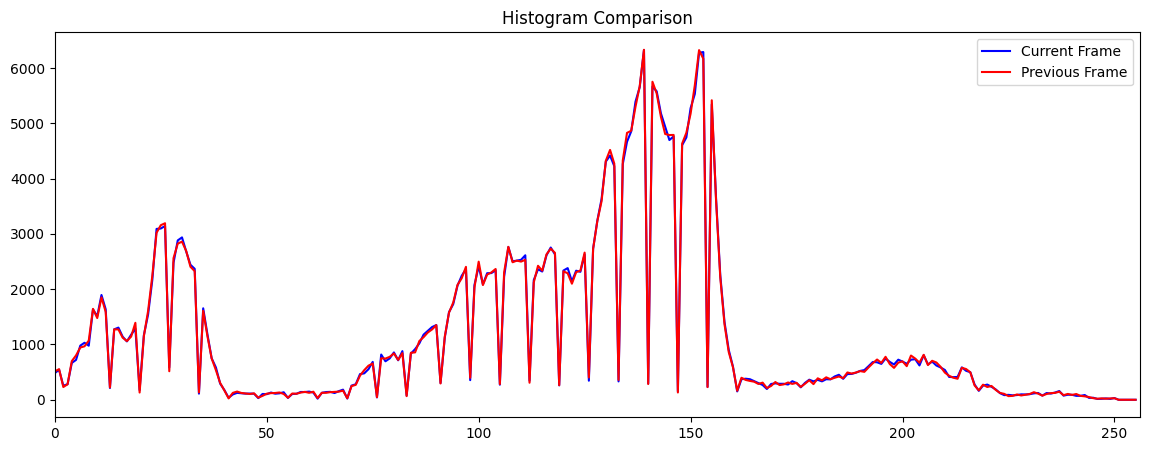

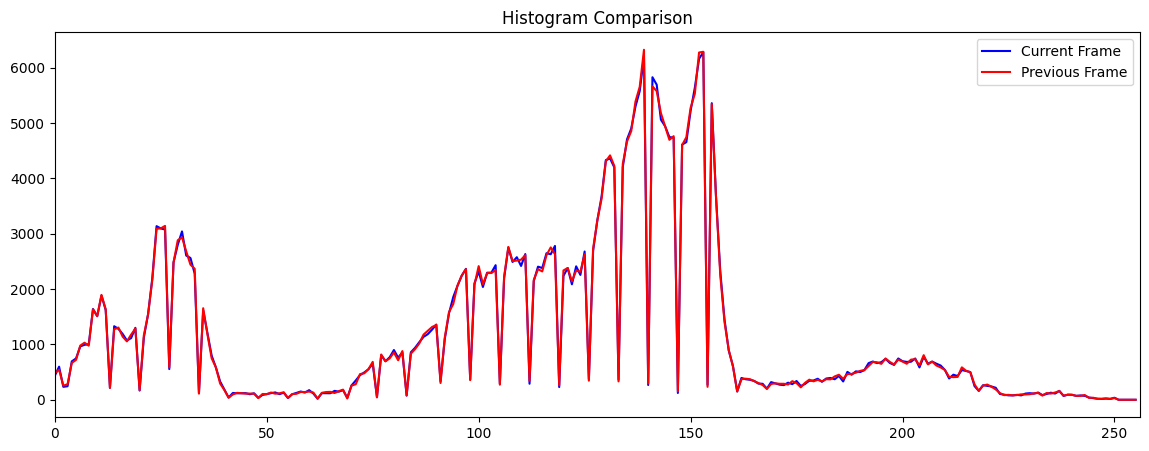

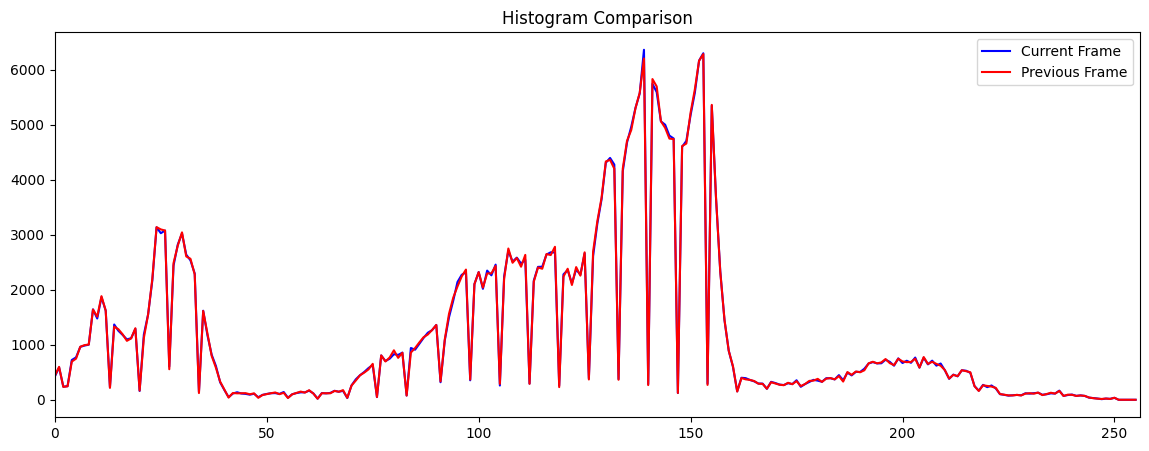

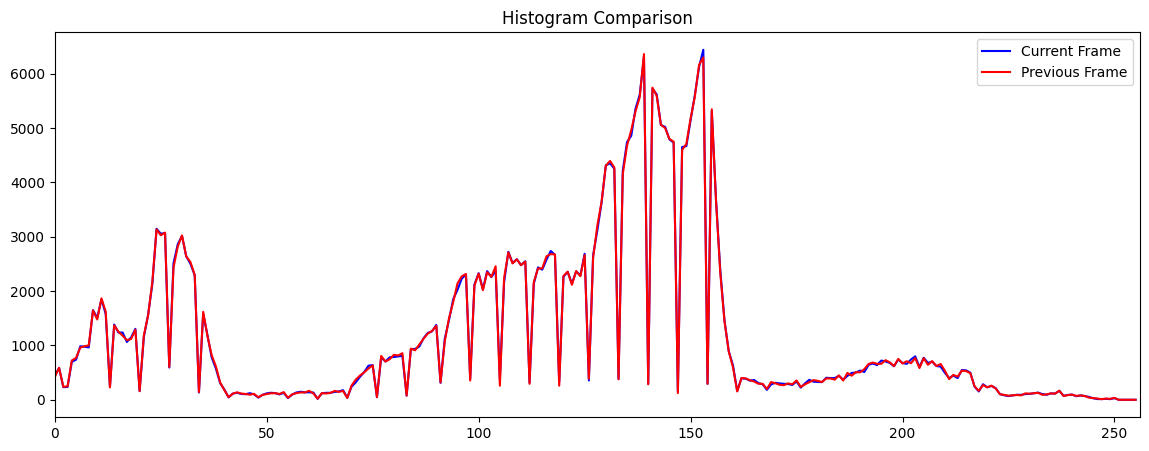

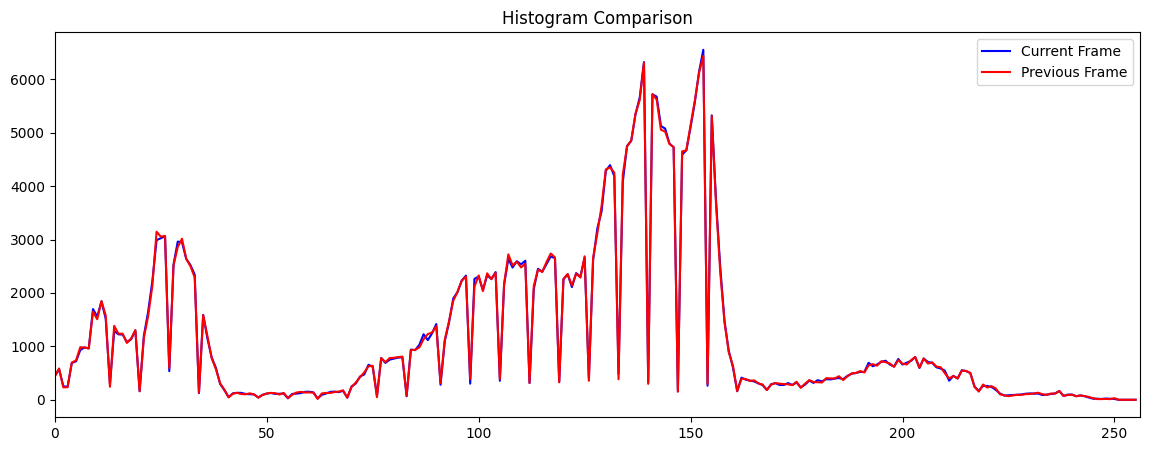

In [103]:
HDiffs = calculate_histogram_differences(gray_frames)

HDiffs = []

# Duyệt qua tất cả các frame trừ frame cuối vì thường là frame không có giá trị
for i in range(0, len(gray_frames)-1):
    if (i == 0):
    #[gray_frames[i]]: grayframe thứ i, [0] kênh chứa độ sáng, None: tính toàn bộ ảnh, không dùng mask, [256]: 256 bins, 0 <=[0, 256]: giá trị pixel < 256
        hist_curr = cv2.calcHist([gray_frames[i]], [0], None, [256], [0, 256])
        continue
    # Gán frame ở vòng lặp trước cho hist_prev và tính lại hist_curr
    hist_prev = hist_curr
    hist_curr = cv2.calcHist([gray_frames[i]], [0], None, [256], [0, 256])

    Hdiff = np.sum(np.abs(hist_prev - hist_curr))
    HDiffs.append(Hdiff)

    # Trực quan 2 Histogram liên tiếp để kiểm tra
    if (15 < i <= 20):
        plt.figure(figsize=(14, 5))
        plt.title("Histogram Comparison")
        plt.plot(hist_curr, color='blue', label='Current Frame')
        plt.plot(hist_prev, color='red', label='Previous Frame')
        plt.xlim([0, 256])
        plt.legend()
        plt.show()

<h3> Tính trung bình và độ lệch chuẩn của mảng Hdiffs và tính ngưỡng Threshold

In [108]:
mean = np.mean(HDiffs)
std = np.std(HDiffs)
threshold = mean + 0.5* std
print (f"Giá trị trung bình của HDiffs: {mean}")
print (f"Độ lệch chuẩn của HDiffs: {std}")
print (f"Ngưỡng threshold: {threshold}")

Giá trị trung bình của HDiffs: 10008.453125
Độ lệch chuẩn của HDiffs: 5982.32421875
Ngưỡng threshold: 12999.615234375


<h3> Trực quan ngưỡng Threshold

Histogram threshold: 12999.615234375


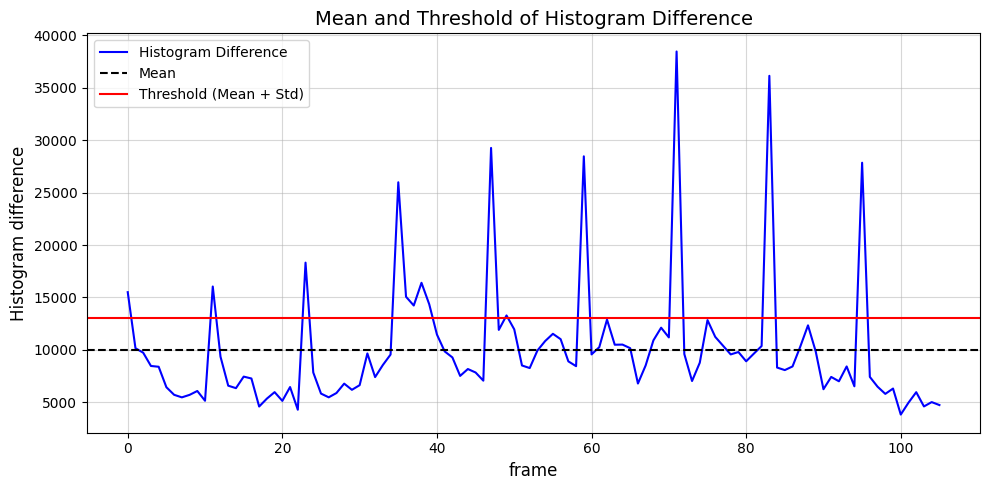

In [109]:
print(f"Histogram threshold: {threshold}")

# Vẽ đồ thị
plt.figure(figsize=(10, 5))
plt.title("Mean and Threshold of Histogram Difference", fontsize=14)
plt.plot(HDiffs, color="blue", label="Histogram Difference")  
plt.axhline(y=mean, color="black", linestyle="--", label="Mean")  
plt.axhline(y=threshold, color="red", linestyle="-", label="Threshold (Mean + Std)")  
plt.xlabel("frame", fontsize=12)
plt.ylabel("Histogram difference", fontsize=12)
plt.legend(fontsize=10) 
plt.grid(alpha=0.5) 
plt.tight_layout()  
plt.show()

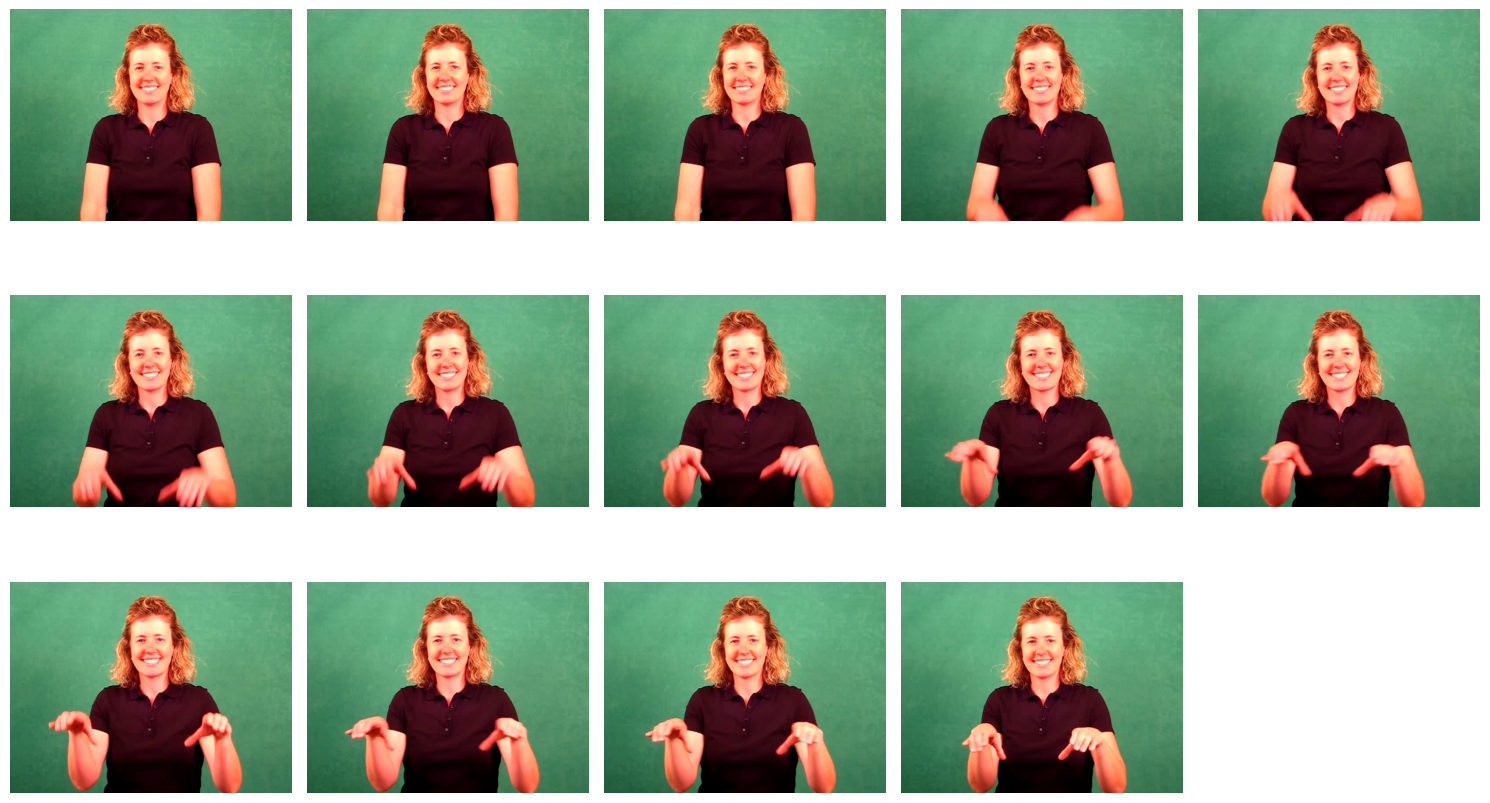

In [110]:
keyframes = []

for i in range(len(HDiffs)):
    if HDiffs[i] > threshold:
        # Lấy frame i+1 vì Hdiffs[i] là độ khác biệt của frame thứ i +1 với thứ i
        keyframes.append(frames[i+1])



# Hiển thị các keyframes
num_frames = len(keyframes)
grid_cols = 5  
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3)) 
for i, rgb_frame in enumerate(keyframes):
    plt.subplot(grid_rows, grid_cols, i + 1)  # Xác định vị trí trong grid
    frame_rgb = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)  # Chuyển đổi BGR sang RGB
    plt.imshow(frame_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()

<h3> Lưu lại các keyframes

In [107]:
path_folder = rf"D:\Study_space\Ki6\sign_language_recognition_project\debug\keyframes\keyframes_{namevideo}"
if not os.path.exists(path_folder):
    os.makedirs(path_folder)
for idx, rgb_frame in enumerate(keyframes):
    frame_path = os.path.join(path_folder , f"key_frame_{idx}.jpg")
    cv2.imwrite(frame_path, rgb_frame)

# Trích xuất landmarks với mediapipe

## Khai báo các hàm 

<h3> Hàm trích xuất các landmarks pose </h3>



<i> Với các landmarks: mũi[0], mắt trái (trong)[1], mắt trái[2], mắt trái (ngoài)[3], mắt phải (trong)[4], mắt phải[5], mắt phải (ngoài)[6], miệng (trái)[9], miệng (phải)[10], vai trái[11], vai phải[12], khuỷu tay trái[13], khuỷu tay phải[14], cổ tay trái[15], cổ tay phải[16]


In [2]:
def extract_pose_landmarks(rgb_frame, mp_pose):
    pose_results = mp_pose.process(rgb_frame)
    pose_landmarks = []

    if pose_results.pose_landmarks:
        for i, lm in enumerate(pose_results.pose_landmarks.landmark):
            if i < 17 and i not in [7, 8]:  # Loại bỏ từ hông trở xuống và 2 tai
                pose_landmarks.append((lm.x, lm.y))

    return pose_landmarks

<h3> Hàm xác định tay trái phải thay cho mediapipe hand </h3>

Tính khoảng cách Euclidean từ cổ tay của landmarks tay đến 2 landmark cổ tay từ mediapose, nếu gần bên nào hơn thì là tay bên đó

In [ ]:
# def euclidean_distance(x1, y1, x2, y2):
#     return np.sqrt((float(x1) - float(x2)) ** 2 + (float(y1) - float(y2)) ** 2)


def classify_hands (pose_landmarks, hand_landmarks):
    left_wrist_pose  = pose_landmarks[13]  # Cổ tay trái từ Pose là 15 trừ đi 2 tai đã lượt bỏ nên idx = 13
    right_wrist_pose = pose_landmarks[14]  # Cổ tay phải từ Pose là 16 trừ đi 2 tai đã lượt bỏ nên idx = 14
    wrist = hand_landmarks[0] 
    

    dleft = euclidean_distance(left_wrist_pose, wrist)
    dright = euclidean_distance(right_wrist_pose, wrist)
   
    if(dleft < dright):
        return "Left"
    else:
        return "Right"

<h3> Hàm trích xuất landmarks 2 tay </h3>

<i>cổ tay[0], gốc ngón cái[1], khớp ngón cái[2], đốt ngón cái[3], đầu ngón cái[4], khớp ngón trỏ[5], đốt ngón trỏ[6], đầu ngón trỏ[7], đầu ngón trỏ[8], khớp ngón giữa[9], đốt ngón giữa[10], đầu ngón giữa[11], đầu ngón giữa[12], khớp ngón áp út[13], đốt ngón áp út[14], đầu ngón áp út[15], đầu ngón út[16], khớp ngón út[17], đốt ngón út[18], đầu ngón út[19], đầu ngón út[20]


In [ ]:
def extract_hand_landmarks(rgb_frame, mp_hands, pose_landmarks):
    hands_results = mp_hands.process(rgb_frame)
    left_hand_landmarks = []
    right_hand_landmarks = []
    
    # prev_type = ""
    # prev_landmarks = []

    if hands_results.multi_hand_landmarks and hands_results.multi_handedness:
        for hand_landmarks, handedness in zip(hands_results.multi_hand_landmarks, hands_results.multi_handedness):
            # Không sử dụng hướng tay của mediapipe vì độ chính xác thấp và thường ngược hướng
            landmarks = [(lm.x, lm.y) for lm in hand_landmarks.landmark]
            if classify_hands(pose_landmarks, landmarks) == "Right":
                right_hand_landmarks = landmarks
            else:
                left_hand_landmarks = landmarks   

            # landmarks = [(lm.x, lm.y) for lm in hand_landmarks.landmark]
            # hand_type = handedness.classification[0].label
            # # Nếu mediapipehand nhận diện nhầm 2 tay cùng 1 hướng thì phân loại thủ công
            # if prev_type == hand_type:
            #     if classify_hands(pose_landmarks, landmarks) == "Right":
            #         right_hand_landmarks = landmarks
            #         left_hand_landmarks = prev_landmarks
            #     else:
            #         left_hand_landmarks = landmarks    
            #         right_hand_landmarks = prev_landmarks
            # else:
            #     # vì mediapipehand nhận dạng ngược hướng tay    
            #     if hand_type == "Left":
            #         right_hand_landmarks = landmarks
            #     elif hand_type == "Right":
            #         left_hand_landmarks = landmarks
            # prev_landmarks = landmarks
            # prev_type = hand_type





        
    
    return left_hand_landmarks, right_hand_landmarks

<h3> Hàm trích xuất landmarks </h3>

Trích xuất landmarks chưa chuẩn hóa

In [ ]:
def extract_landmarks(frames):
    mp_pose = mp.solutions.pose.Pose(static_image_mode=True)
    mp_hands = mp.solutions.hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.1)
    
    landmarks_dict = {}
    
    for idx, frame in enumerate(frames):
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        pose_landmarks = extract_pose_landmarks(rgb_frame, mp_pose)
        left_hand_landmarks, right_hand_landmarks = extract_hand_landmarks(rgb_frame, mp_hands ,pose_landmarks)
        
        landmarks_dict[idx] = {
            "pose": pose_landmarks,
            "left": left_hand_landmarks,
            "right": right_hand_landmarks
        }
    #giải phóng tài nguyên
    mp_pose.close()
    mp_hands.close()
    return landmarks_dict

<h3> Hàm xử lí các giá trị không hợp lệ</h3>

Nếu không phát hiện tay thì khởi tạo nó về điểm (0,0). Nếu landmark nằm ngoài phạm vi (0,1) thì nằm ngoài ảnh nên cũng đưa về (0,0). (0,0 là góc trên trái)

In [ ]:
def filter_invalid_landmarks(landmarks_dict):
    validated = {}
    for landmarks_idx, landmarks_data in landmarks_dict.items():
        validated_landmarks = {}
        # Nếu không có pose thì bỏ qua frame
        if  not landmarks_data["pose"]:
            continue
        for part in ["pose", "right", "left"]:
            # Nếu không có dữ liệu cho phần này, gán mặc định
            if part not in landmarks_data or not landmarks_data[part]:
                if part in ["right", "left"]:
                    validated_landmarks[part] = [(0.0, 0.0)] * 21
            else:
                processed_points = []
                for point in landmarks_data[part]:
                    x = float(point[0])
                    y = float(point[1])
                    if not (0.0 <= x <= 1.0 and 0.0 <= y <= 1.0):
                        x, y = 0.0, 0.0
                    processed_points.append((x, y))
                validated_landmarks[part] = processed_points
        validated[landmarks_idx] = validated_landmarks
    return validated


<h3> Hàm xuất ảnh đã gán landmarks cho kiểm thử

In [ ]:
CUSTOM_POSE_CONNECTIONS = [
    (0, 1), (0, 4),         # mũi - 2 mắt 
    (4, 5), (5, 6),         # mắt phải
    (1, 2), (2, 3),         # mắt trái
    # vì bỏ 2 tai nên mỗi landmarks phía sau giảm index đi 2
    (7, 8),                # miệng
    (9, 10),               # 2 vai
    (10, 12), (12, 14),     # tay phải
    (9, 11), (11, 13),     # tay trái
]

def draw_landmarks(frame, landmarks_dict):
    h, w, _ = frame.shape  
    annotated_frame = frame.copy()

    pose_landmarks = landmarks_dict.get("pose", [])
    left_hand_landmarks = landmarks_dict.get("left", [])
    right_hand_landmarks = landmarks_dict.get("right", [])

    # Vẽ đường nối Pose (sử dụng kết nối tùy chỉnh)
    if pose_landmarks and len(pose_landmarks) > 0:
        for idx1, idx2 in CUSTOM_POSE_CONNECTIONS:
            if idx1 < len(pose_landmarks) and idx2 < len(pose_landmarks):
                x1, y1 = pose_landmarks[idx1]
                x2, y2 = pose_landmarks[idx2]
                if x1 and y1 and x2 and y2:
                    x1, y1 = int(x1 * w), int(y1 * h)
                    x2, y2 = int(x2 * w), int(y2 * h)
                    cv2.line(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 5)

    # Vẽ đường nối Tay trái/phải
    mp_hands = mp.solutions.hands
    hand_connections = list(mp_hands.HAND_CONNECTIONS)
    # thang màu BGR, gán xanh dương cho tay trái, đỏ cho tay phải
    for hand, landmarks, color in [("left", left_hand_landmarks, (255, 0, 0)), ("right", right_hand_landmarks, (0, 0, 255))]:
        if landmarks and len(landmarks) > 0:
            for idx1, idx2 in hand_connections:
                if idx1 < len(landmarks) and idx2 < len(landmarks):
                    x1, y1 = landmarks[idx1]
                    x2, y2 = landmarks[idx2]
                    if x1 and y1 and x2 and y2:
                        x1, y1 = int(x1 * w), int(y1 * h)
                        x2, y2 = int(x2 * w), int(y2 * h)
                        cv2.line(annotated_frame, (x1, y1), (x2, y2), color, 2)

    # Vẽ các điểm landmarks
    for part, landmarks, color in zip(["pose", "left", "right"], 
                                      [pose_landmarks, left_hand_landmarks, right_hand_landmarks], 
                                      [(0, 255, 0), (255, 0, 0), (0, 0, 255)]):
        if landmarks and len(landmarks) > 0:
            for x, y in landmarks:
                if x and y:
                    x, y = int(x * w), int(y * h)
                    cv2.circle(annotated_frame, (x, y), 5, color, -1)

    return annotated_frame


## Kiểm thử

In [ ]:
namevideo = "17960"
# namevideo = "66546"

video_path = rf'D:\Study_space\Ki6\sign_language_recognition_project\Sign_Language_Recognition\data\raw\videos\{namevideo}.mp4' 

# Trích xuất keyframes từ video
keyframes = Extract_key_frames(video_path)

# Trích xuất landmarks từ keyframes
landmarks_dict = extract_landmarks(keyframes)

landmarks_dict = filter_invalid_landmarks(landmarks_dict)


NameError: name 'Extract_key_frames' is not defined

In [ ]:
#vẽ các landmarks lên keyframes để kiểm tra
annotated_frames = []
for idx, landmarks_dictIdx in landmarks_dict.items():
    annotated_frame = draw_landmarks(keyframes[idx], landmarks_dictIdx)  
    annotated_frames.append(annotated_frame)


num_frames = len(annotated_frames)
grid_cols = 5  
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3)) 
for i, rgb_frame in enumerate(annotated_frames):
    plt.subplot(grid_rows, grid_cols, i + 1)  # Xác định vị trí trong grid
    frame_rgb = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)  # Chuyển đổi BGR sang RGB
    plt.imshow(frame_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'landmarks_dict' is not defined

<h3>Lưu lại các ảnh đã gắn landmarks

In [ ]:
path_folder = rf"D:\Study_space\Ki6\sign_language_recognition_project\debug\annotateds\annotateds_{namevideo}"
if not os.path.exists(path_folder):
    os.makedirs(path_folder)
for idx, rgb_frame in enumerate(annotated_frames):
    frame_path = os.path.join(path_folder , f"annotated_frame_{idx}.jpg")
    cv2.imwrite(frame_path, rgb_frame)

# Tăng cường dữ liệu

*Note: tăng cường trước, sau đó mới filter_invalid_landmarks

## Khai báo các hàm 

<h3> Hàm xoay landmarks </h3>

Xoay tọa độ điểm quanh tâm (0.5, 0.5) theo góc angle_deg (độ).

Công thức:

* x' = (x - 0.5)*cos(q) - (y - 0.5)*sin(q) + 0.5 

* y' = (x - 0.5)*sin(q) + (y - 0.5)*cos(q) + 0.5

In [ ]:
def rotate_landmarks(landmarks, angle_deg, center):
    transformed = {}
    theta = np.radians(angle_deg)
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    cx, cy = center
    
    for key in landmarks:
        if landmarks[key]:
            points = np.array(landmarks[key], dtype=np.float32)
            transformed_points = []
            for x, y in points:
                x_new = cx + (x - cx) * cos_theta - (y - cy) * sin_theta
                y_new = cy + (x - cx) * sin_theta + (y - cy) * cos_theta
                transformed_points.append([x_new, y_new])
            transformed[key] = transformed_points
        else:
            transformed[key] = []
    return transformed

<h3> Hàm dịch chuyển </h3>

Dịch landmarks theo tx,ty

In [ ]:
def translate_landmarks(landmarks, tx, ty):
    transformed = {}
    for key in landmarks:
        if landmarks[key]:
            points = np.array(landmarks[key], dtype=np.float32)
            transformed_points = []
            for x, y in points:
                x_new = x + tx
                y_new = y + ty
                transformed_points.append([x_new, y_new])
            transformed[key] = transformed_points
        else:
            transformed[key] = []
    return transformed

<h3> Hàm thêm nhiễu </h3>

Cộng thêm 1 noise ngẫu nhiên vào cả landmarks

In [ ]:
def add_noise_to_landmarks(landmarks, noise_level):
    noisy = {}
    for key in landmarks:
        if landmarks[key]:
            points = np.array(landmarks[key], dtype=np.float32)
            noise = np.random.uniform(-noise_level, noise_level, points.shape)
            noisy_points = points + noise
            noisy[key] = noisy_points.tolist()
        else:
            noisy[key] = []
    return noisy

<h3> Hàm squeeze</h3>

Thay đổi landmarks bằng cách nhân với tỉ lệ ngẫu nhiên cho 2 trục x,y và < max_squeeze %

In [ ]:
def squeeze_landmarks(landmarks, squeeze_x, squeeze_y): 
    # Dictionary để lưu landmarks đã biến đổi
    transformed = {}
    
    # Xử lý từng loại landmarks (pose, left_hand, right_hand, v.v.)
    for key in landmarks:
        if landmarks[key]:  # Nếu danh sách điểm không rỗng
            points = np.array(landmarks[key], dtype=np.float32)
            squeezed_points = points * [squeeze_x, squeeze_y]
            transformed[key] = squeezed_points.tolist()
        else:
            transformed[key] = []  # Giữ nguyên nếu không có điểm
    
    return transformed

<h3> Hàm chiếu phối cảnh</h3>

Thực hiện biến đổi phối cảnh ngẫu nhiên lên một ảnh và các điểm landmarks

In [ ]:
# hàm tạo pts2 cho phép chiếu phối cảnh
def generate_pts2(max_shift=0.15):
    top_left = [np.random.uniform(0, max_shift), np.random.uniform(0, max_shift)]
    top_right = [1 - np.random.uniform(0, max_shift), np.random.uniform(0, max_shift)]
    bottom_right = [1 - np.random.uniform(0, max_shift), 1 - np.random.uniform(0, max_shift)]
    bottom_left = [np.random.uniform(0, max_shift), 1 - np.random.uniform(0, max_shift)]

    return np.float32([top_left, top_right, bottom_right, bottom_left])

In [ ]:
def perspective_transform(landmarks, pts2):
    # Định nghĩa 4 điểm gốc trong không gian [0,1]
    pts1 = np.float32([[0, 0], [1, 0], [1, 1], [0, 1]])
    
    # Tính toán ma trận biến đổi phối cảnh
    M = cv2.getPerspectiveTransform(pts1, pts2)
    
    # Biến đổi landmarks
    transformed = {}
    for key in landmarks:
        if landmarks[key]:
            # Chuyển danh sách landmarks thành mảng numpy để áp dụng biến đổi
            points = np.array(landmarks[key], dtype=np.float32)
            # Áp dụng biến đổi phối cảnh
            # reshape(-1, 1, 2): N hàng, mỗi hàng có 1 điểm chứa 2 giá trị x,y
            # reshape(-1, 2): N hàng, 2 giá trị x,y
            transformed_points = cv2.perspectiveTransform(points.reshape(-1, 1, 2), M).reshape(-1, 2)
            # Không chuẩn hóa, giữ nguyên tọa độ sau biến đổi
            transformed[key] = transformed_points.tolist()
        else:
            transformed[key] = []
    
    return transformed

<h3> Hàm gọi tất cả phép tăng cường

In [ ]:
def augment_data(landmarks_dict):
    
    rotated_landmarks_dict = {}
    #quay ngẫu nhiên 1 góc < 15 độ
    angle = np.random.uniform(-15, 15)
    center = (0.5,0.5)
    
    translated_landmarks_dict = {}
    #dịch chuyển 1 khoảng ngẫu nhiên <10%
    dx, dy = np.random.uniform(-0.1, 0.1, 2)
    
    added_noise_landmarks_dict = {}
    #nhiễu < 2%
    noise_level = 0.02

    # squeeze tối đa 15%
    max_squeeze = 0.15 
    squeeze_x = np.random.uniform(1 - max_squeeze, 0.95)
    squeeze_y = np.random.uniform(1 - max_squeeze, 0.95)
    squeezed_landmarks_dict = {}

    perspectived_landmarks_dict = {}
    max_shift = 0.15  # Hệ số dịch chuyển tối đa ±15%

    # Tạo pts2 ngẫu nhiên
    pts2 = generate_pts2(max_shift)

    for idx, landmarks_dictIdx in landmarks_dict.items():
        rotated_landmarks_dict[idx] = rotate_landmarks(landmarks_dictIdx, angle, center)
        translated_landmarks_dict[idx] = translate_landmarks(landmarks_dictIdx, dx , dy)
        added_noise_landmarks_dict[idx] = add_noise_to_landmarks(landmarks_dictIdx, noise_level)
        squeezed_landmarks_dict[idx] = squeeze_landmarks(landmarks_dictIdx, squeeze_x, squeeze_y)
        perspectived_landmarks_dict[idx] = perspective_transform(landmarks_dictIdx, pts2)
    return rotated_landmarks_dict, translated_landmarks_dict, added_noise_landmarks_dict, perspectived_landmarks_dict, squeezed_landmarks_dict


## Kiểm thử


Lấy keyframes và landmarks

In [ ]:
namevideo = "17960"
video_path = rf'D:\Study_space\Ki6\sign_language_recognition_project\Sign_Language_Recognition\data\raw\videos\{namevideo}.mp4' 

# Trích xuất keyframes từ video
keyframes = Extract_key_frames(video_path)

# Trích xuất landmarks từ keyframes
landmarks_dict = extract_landmarks(keyframes)

Kiểm thử xoay

10.4541384902185


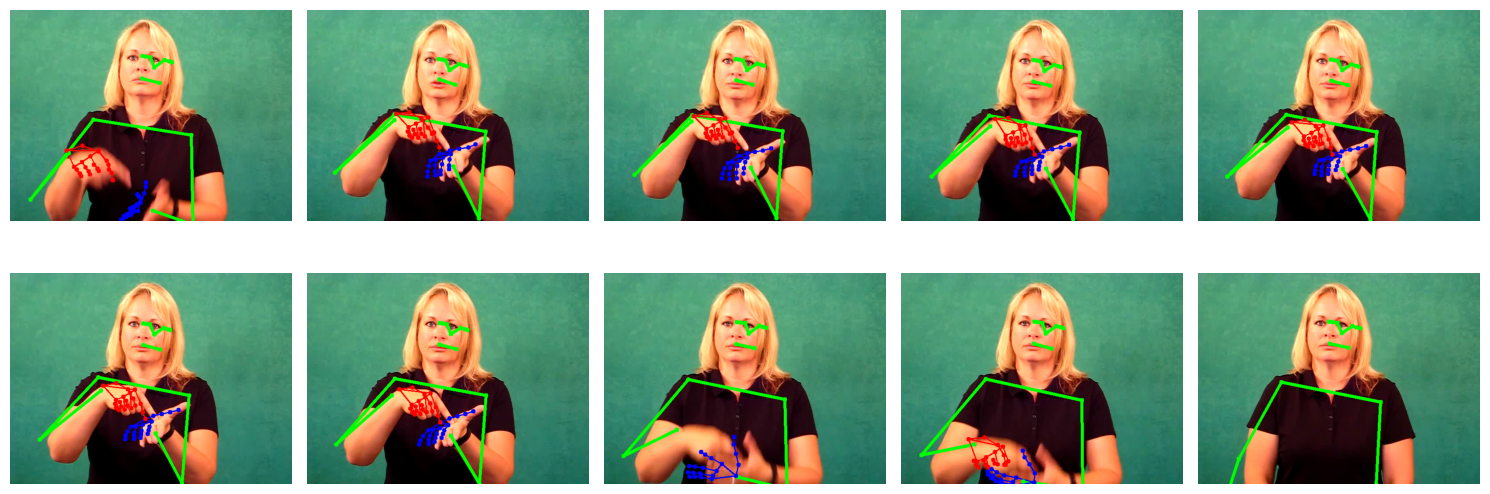

In [ ]:
augmented_landmarks_dict = {}
angle = np.random.uniform(-15, 15)
print(angle)
center = (0.5,0.5)
for idx, landmarks_dictIdx in landmarks_dict.items():
    augmented_landmarks_dict[idx] = rotate_landmarks(landmarks_dictIdx, angle, center)
    

#vẽ các landmarks lên keyframes để kiểm tra
annotated_frames = []
for idx, augmented_landmarks in augmented_landmarks_dict.items(): 
    annotated_frame = draw_landmarks(keyframes[idx], augmented_landmarks)  
    annotated_frames.append(annotated_frame)


num_frames = len(annotated_frames)
grid_cols = 5  
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3)) 
for i, rgb_frame in enumerate(annotated_frames):
    plt.subplot(grid_rows, grid_cols, i + 1)  # Xác định vị trí trong grid
    frame_rgb = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)  # Chuyển đổi BGR sang RGB
    plt.imshow(frame_rgb)
    plt.axis('off')

plt.tight_layout()

plt.show()

Kiểm thử dịch chuyển

0.035252151144346294 0.09606738453169406


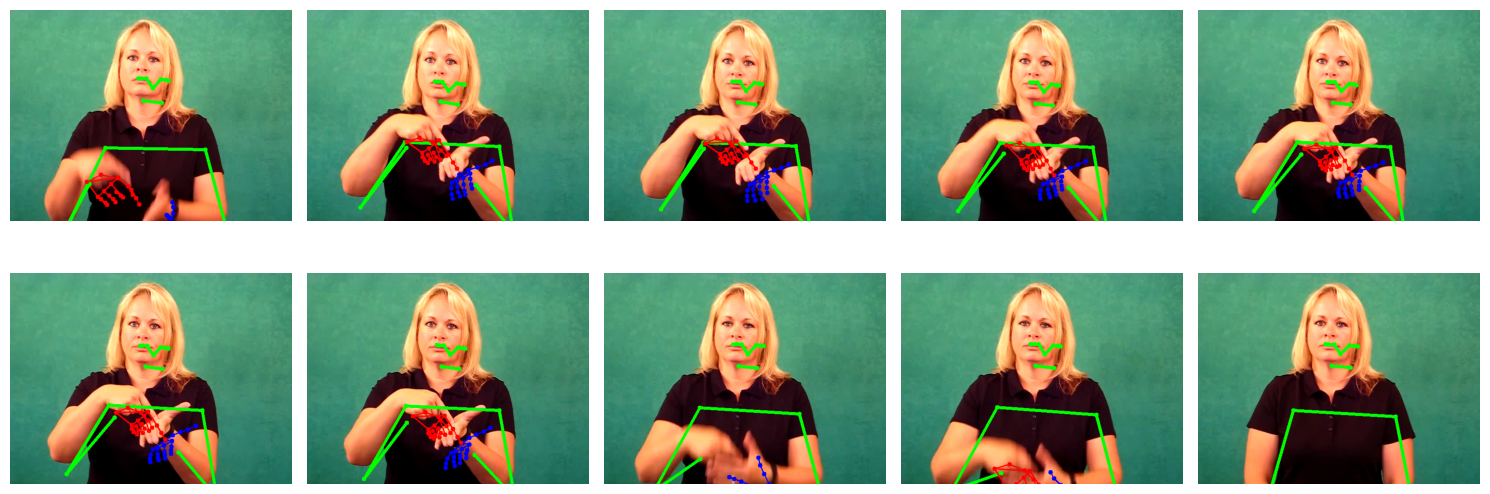

In [ ]:
augmented_landmarks_dict = {}
dx, dy = np.random.uniform(-0.1, 0.1, 2)
print(dx,dy)
for idx, landmarks_dictIdx in landmarks_dict.items():
    augmented_landmarks_dict[idx] = translate_landmarks(landmarks_dictIdx, dx , dy)
    

#vẽ các landmarks lên keyframes để kiểm tra
annotated_frames = []
for idx, augmented_landmarks in augmented_landmarks_dict.items(): 
    annotated_frame = draw_landmarks(keyframes[idx], augmented_landmarks)  
    annotated_frames.append(annotated_frame)


num_frames = len(annotated_frames)
grid_cols = 5  
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3)) 
for i, rgb_frame in enumerate(annotated_frames):
    plt.subplot(grid_rows, grid_cols, i + 1)  # Xác định vị trí trong grid
    frame_rgb = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)  # Chuyển đổi BGR sang RGB
    plt.imshow(frame_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()

Kiểm thử thêm nhiễu

0.02


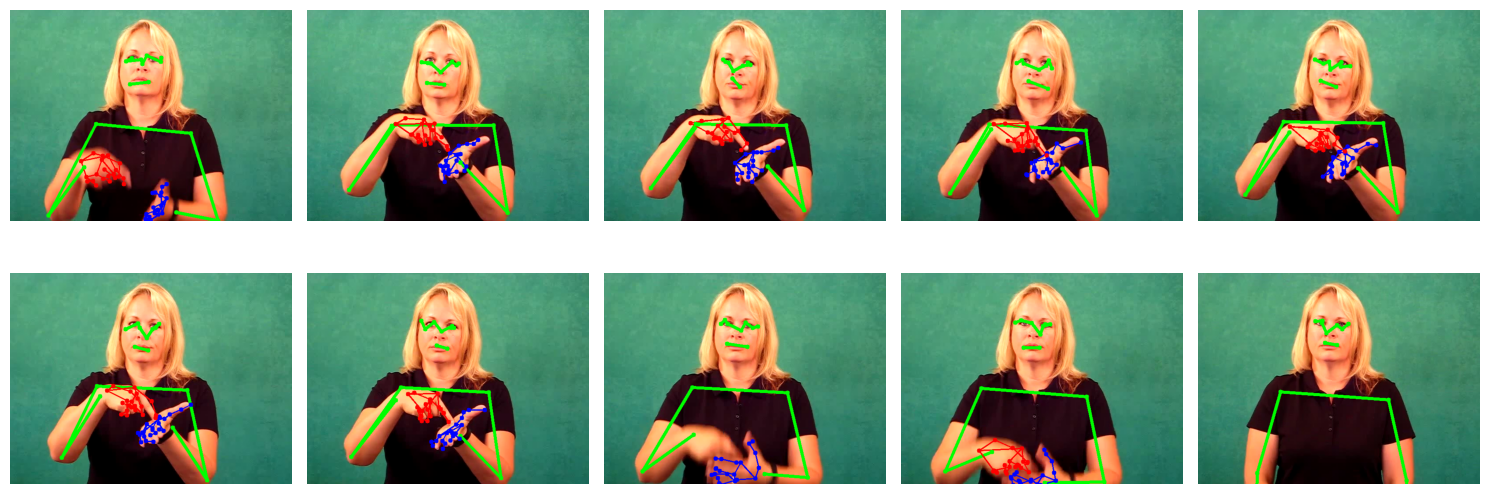

In [ ]:
augmented_landmarks_dict = {}
noise_level = 0.02
print(noise_level)
for idx, landmarks_dictIdx in landmarks_dict.items():
    augmented_landmarks_dict[idx] = add_noise_to_landmarks(landmarks_dictIdx, noise_level)
    

#vẽ các landmarks lên keyframes để kiểm tra
annotated_frames = []
for idx, augmented_landmarks in augmented_landmarks_dict.items(): 
    annotated_frame = draw_landmarks(keyframes[idx], augmented_landmarks)  
    annotated_frames.append(annotated_frame)


num_frames = len(annotated_frames)
grid_cols = 5  
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3)) 
for i, rgb_frame in enumerate(annotated_frames):
    plt.subplot(grid_rows, grid_cols, i + 1)  # Xác định vị trí trong grid
    frame_rgb = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)  # Chuyển đổi BGR sang RGB
    plt.imshow(frame_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()

Kiểm thử squeeze

0.15


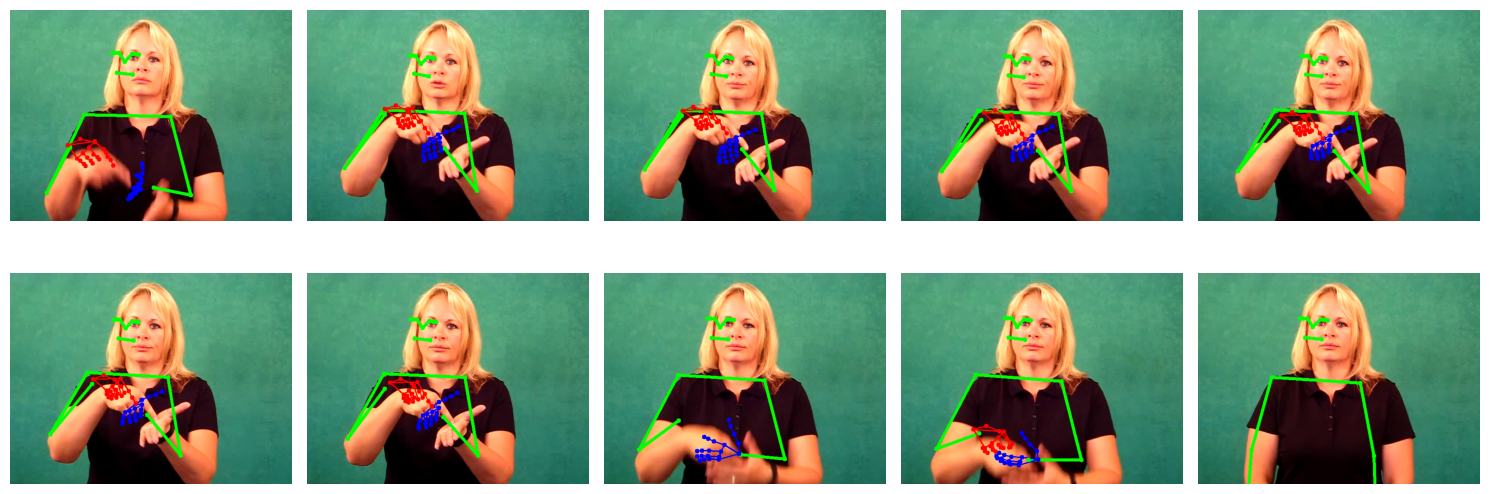

In [ ]:
augmented_landmarks_dict = {}
max_squeeze = 0.15
squeeze_x = np.random.uniform(1 - max_squeeze, 0.95)
squeeze_y = np.random.uniform(1 - max_squeeze, 0.95)
print(max_squeeze)
for idx, landmarks_dictIdx in landmarks_dict.items():
    augmented_landmarks_dict[idx] = squeeze_landmarks(landmarks_dictIdx, squeeze_x, squeeze_y)
    

#vẽ các landmarks lên keyframes để kiểm tra
annotated_frames = []
for idx, augmented_landmarks in augmented_landmarks_dict.items(): 
    annotated_frame = draw_landmarks(keyframes[idx], augmented_landmarks)  
    annotated_frames.append(annotated_frame)


num_frames = len(annotated_frames)
grid_cols = 5  
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3)) 
for i, rgb_frame in enumerate(annotated_frames):
    plt.subplot(grid_rows, grid_cols, i + 1)  # Xác định vị trí trong grid
    frame_rgb = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)  # Chuyển đổi BGR sang RGB
    plt.imshow(frame_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Kiểm thử phép chiếu phối cảnh


[[0.02649005 0.03440711]
 [0.9515122  0.11868344]
 [0.98815984 0.92960817]
 [0.08662888 0.9391544 ]]


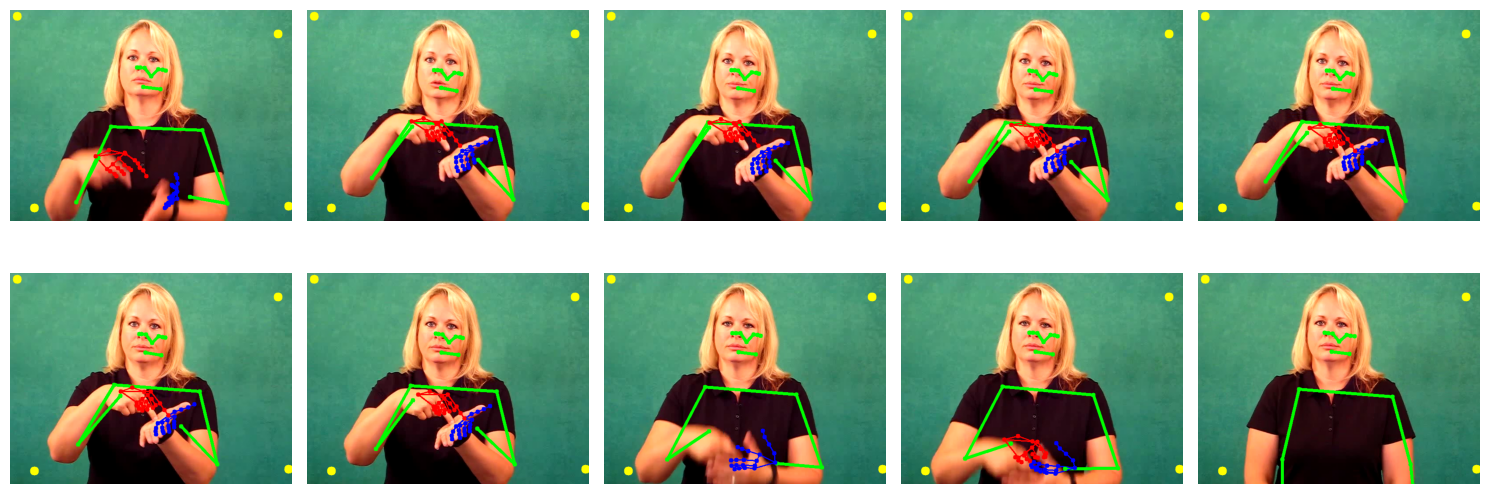

In [ ]:

augmented_landmarks_dict = {}

perspectived_landmarks_dict = {}
max_shift = 0.15  # Hệ số dịch chuyển tối đa ±15%

# Tạo pts2 ngẫu nhiên
pts2 = generate_pts2(max_shift)
print(pts2)

for idx, landmarks_dictIdx in landmarks_dict.items():
    augmented_landmarks_dict[idx] = perspective_transform(landmarks_dictIdx,pts2)

#vẽ các landmarks lên keyframes để kiểm tra
annotated_frames = []
for idx, augmented_landmarks in augmented_landmarks_dict.items(): 
    annotated_frame = draw_landmarks(keyframes[idx], augmented_landmarks)  
    # Vẽ các điểm pts2 lên frame
    h, w, _ = annotated_frame.shape
    for x, y in pts2:
        cv2.circle(annotated_frame, (int(x * w), int(y * h)), 10, (0, 255, 255), -1)  # Vẽ điểm màu vàng
    annotated_frames.append(annotated_frame)


num_frames = len(annotated_frames)
grid_cols = 5  
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3)) 
for i, rgb_frame in enumerate(annotated_frames):
    plt.subplot(grid_rows, grid_cols, i + 1)  # Xác định vị trí trong grid
    frame_rgb = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)  # Chuyển đổi BGR sang RGB
    plt.imshow(frame_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Chuẩn hóa với sign space (bounding box)

## Khai báo các hàm

<h3>Tính đơn vị đầu</h3>

In [ ]:
def calculate_head_unit(pose_landmarks):

    left_eye, right_eye = pose_landmarks[3], pose_landmarks[6]
    # mép ngoài 2 mắt
    head_unit = euclidean_distance(left_eye,right_eye)
    return head_unit

<h3>Tính không gian chuẩn hóa</h3>

Không gian chuẩn hóa với mũi là trung tâm, mép trên cách 1.5 đơn vị đầu, mép dưới cách 8 đơn vị đầu, mép trái phải cách mũi 3.5 đơn vị đầu. Với đơn vị đầu được quy định là khoảng cách giữa 2 landmark ngoài của mỗi mắt


In [ ]:
def calculate_sign_space(pose_landmarks):
    head_unit = calculate_head_unit(pose_landmarks)

    nose = pose_landmarks[0]
   
   
    width = 7 * head_unit
    # height = 9.5 * head_unit 
    
    center_x, center_y = nose

    x1 = center_x - width / 2

    y1 = center_y - 1.5 * head_unit  # Cạnh trên cách 1,5 head unit
    x2 = center_x + width / 2
    # y2 = min(1.0 , int(center_y + 7.5 * head_unit))
    y2 = center_y + 8 * head_unit 
    return [x1, y1, x2, y2]

Vẽ sign space lên frame để debug

In [ ]:
def draw_normalized_sign_space(frame, sign_space):
    x1, y1, x2, y2 = sign_space
    h, w, _ = frame.shape

    # Convert normalized coordinates to pixel coordinates
    x1_pixel, y1_pixel = int(x1 * w), int(y1 * h)
    x2_pixel, y2_pixel = int(x2 * w), int(y2 * h)

    # Draw the bounding box on the frame
    annotated_frame = frame.copy()
    cv2.rectangle(annotated_frame, (x1_pixel, y1_pixel), (x2_pixel, y2_pixel), (0, 255, 0), 2)

    return annotated_frame

Tính tất cả sign space của 1 video

In [ ]:
def calculate_all_sign_space(landmarks_dict):
    sign_spaces = {}
    for idx, landmarks_data in landmarks_dict.items():
        sign_spaces[idx] = calculate_sign_space(landmarks_data["pose"])
    return sign_spaces

Chuẩn hóa landmarks vào sign space

In [ ]:
def normalize_landmarks_to_sign_space(landmarks_dict, sign_spaces):
    
    normalized = {}
    for landmarks_idx, landmarks_data in landmarks_dict.items():
        Xmin, Ymin, Xmax, Ymax = sign_spaces[landmarks_idx]
        w = Xmax - Xmin
        h = Ymax - Ymin
        normalized_landmarks = {}
        for part in ["pose", "right", "left"]:
            processed_points = []
            for point in landmarks_data[part]:
                x = float(point[0])
                y = float(point[1])
                if x != 0.0 and y != 0.0:
                   x = (x - Xmin) / w
                   y = (y - Ymin) / h
                processed_points.append((x, y))
            normalized_landmarks[part] = processed_points
        normalized[landmarks_idx] = normalized_landmarks
    return normalized

## Kiểm thử

[INFO] Sign Space Box: (0.08928532454549193%, 0.11467321026827149%), (0.8527371778768409%, 1.1507864397893879%)
[INFO] Sign Space Box: (0.09969529139848893%, 0.1338227077375665%), (0.8345185257211094%, 1.1310828114611229%)
[INFO] Sign Space Box: (0.09764772742344979%, 0.1321957540910331%), (0.8403753629390991%, 1.1401832594336998%)
[INFO] Sign Space Box: (0.10794261601353189%, 0.13948820108509277%), (0.8348799595556209%, 1.1260460244636423%)
[INFO] Sign Space Box: (0.11136767139481074%, 0.13542761066320352%), (0.8357526374812269%, 1.118521493209054%)
[INFO] Sign Space Box: (0.11957355640504352%, 0.14482078084849287%), (0.8277491102400065%, 1.1059161753387998%)
[INFO] Sign Space Box: (0.11065374765770442%, 0.1395714536478554%), (0.8351934656105756%, 1.122875356583895%)
[INFO] Sign Space Box: (0.09755669862833138%, 0.13064534677269848%), (0.8524518129149425%, 1.1551458590188135%)
[INFO] Sign Space Box: (0.09677618177541408%, 0.12905508037894248%), (0.854547208231605%, 1.157458616283773%)

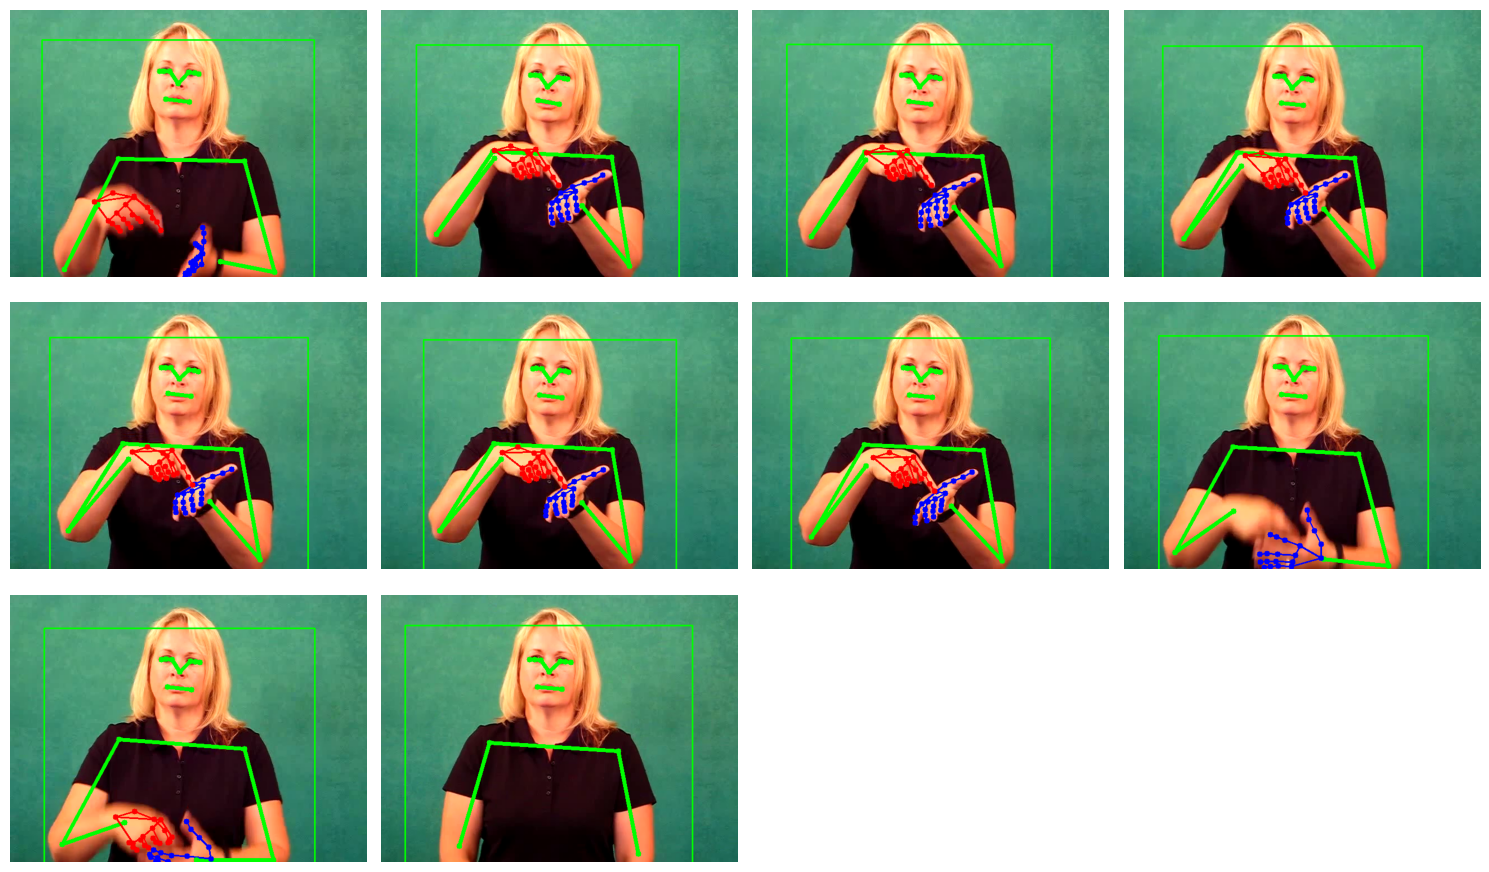

In [ ]:
namevideo = "17960"
# namevideo = "00962"
# namevideo = "03563"
# namevideo = "07933"
video_path = rf'D:\Study_space\Ki6\sign_language_recognition_project\Sign_Language_Recognition\data\raw\videos\{namevideo}.mp4' 


# Trích xuất keyframes từ video
keyframes = Extract_key_frames(video_path)

# Trích xuất landmarks từ keyframes
landmarks_dict = extract_landmarks(keyframes)
# Xử lí các giá trị không hợp lệ
landmarks_dict = filter_invalid_landmarks(landmarks_dict)

sign_spaces = calculate_all_sign_space(landmarks_dict)

annotated_frames = []
for idx, landmarks_dictIdx in landmarks_dict.items():
    annotated_frame = draw_landmarks(keyframes[idx], landmarks_dictIdx)  
    annotated_frame = draw_normalized_sign_space(annotated_frame, sign_spaces[idx])
    annotated_frames.append(annotated_frame)


num_frames = len(annotated_frames)
grid_cols = 4  
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3)) 
for i, rgb_frame in enumerate(annotated_frames):
    plt.subplot(grid_rows, grid_cols, i + 1)  # Xác định vị trí trong grid
    frame_rgb = cv2.cvtColor(rgb_frame, cv2.COLOR_BGR2RGB)  # Chuyển đổi BGR sang RGB
    plt.imshow(frame_rgb)
    plt.axis('off')

plt.tight_layout()
plt.show()

{'pose': [(0.49999999999999994, 0.15789473684210525), (0.5382338919260536, 0.11775249049009763), (0.5605521058440202, 0.11973395576449862), (0.5748701459093362, 0.12279969282765556), (0.4693252500044566, 0.11365576616409388), (0.44704896105412845, 0.11264315882678332), (0.4325755956198803, 0.11346694766459026), (0.5415956965936682, 0.2233910118372629), (0.45578606185191634, 0.2136839087229386), (0.744550951665664, 0.43654272064556227), (0.2809830712225543, 0.42851336819885116), (0.8533483506465497, 0.8375594451521571), (0.08158035209552998, 0.8264531953745143), (0.6552568602559997, 0.7990722262421388), (0.205921959818165, 0.5943122046567326)], 'right': [(0.1935579199205466, 0.5843258359758488), (0.2597625575745985, 0.5519408673981774), (0.3391438143873123, 0.568599983192451), (0.3865346032954958, 0.603197503620045), (0.40636464455306115, 0.6425236985363885), (0.33905172779638215, 0.5642399427031893), (0.3997829321055094, 0.6208569015589964), (0.42308169840905197, 0.6573311878416612), (

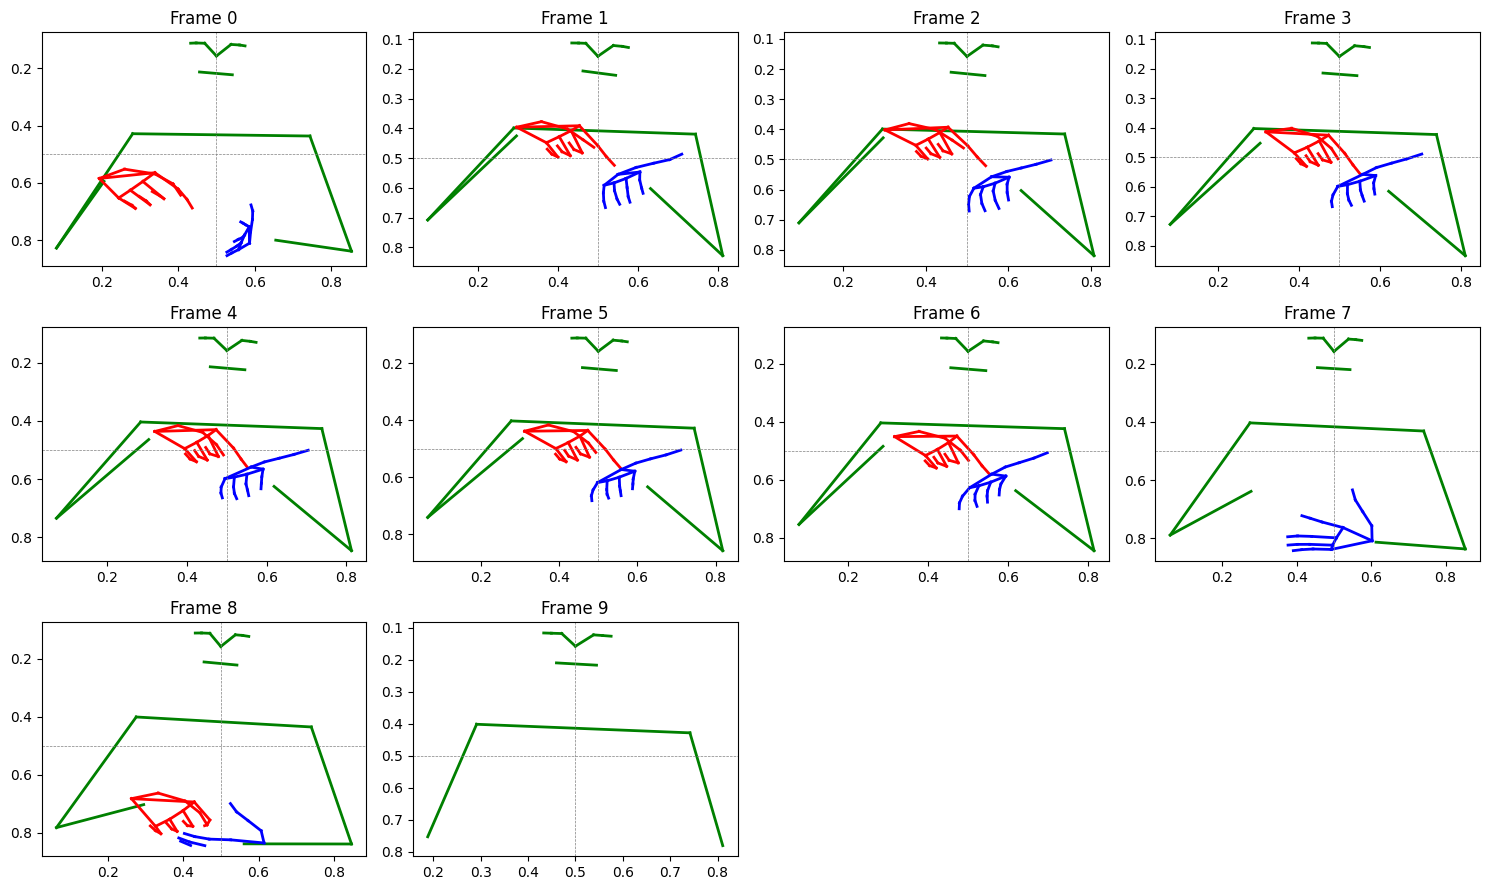

In [ ]:
normalized_landmarks_dict = normalize_landmarks_to_sign_space(landmarks_dict,sign_spaces)

print(normalized_landmarks_dict[0])



# Vẽ các landmarks đã được chuẩn hóa lên keyframes để kiểm tra
num_frames = len(normalized_landmarks_dict)
grid_cols = 4  # 4 hình trên 1 hàng
grid_rows = np.ceil(num_frames / grid_cols).astype(int)  # Tính số hàng cần thiết

plt.figure(figsize=(15, grid_rows * 3))
for idx, normalized_landmarks in normalized_landmarks_dict.items():
    plt.subplot(grid_rows, grid_cols, idx + 1)  # Xác định vị trí trong grid
    
    # Vẽ các điểm pose và nối chúng theo CUSTOM_POSE_CONNECTIONS
    pose_x = [point[0] for point in normalized_landmarks["pose"]]
    pose_y = [point[1] for point in normalized_landmarks["pose"]]
    for connection in CUSTOM_POSE_CONNECTIONS:
        idx1, idx2 = connection
        if idx1 < len(pose_x) and idx2 < len(pose_x):
            if (pose_x[idx1], pose_y[idx1]) != (0.0, 0.0) and (pose_x[idx2], pose_y[idx2]) != (0.0, 0.0):
                plt.plot([pose_x[idx1], pose_x[idx2]], [pose_y[idx1], pose_y[idx2]], color="green", linewidth=2)

    # Vẽ các điểm right hand và nối chúng
    right_hand_x = [point[0] for point in normalized_landmarks["right"]]
    right_hand_y = [point[1] for point in normalized_landmarks["right"]]
    if right_hand_x and right_hand_y:
        for connection in mp.solutions.hands.HAND_CONNECTIONS:
            idx1, idx2 = connection
            if idx1 < len(right_hand_x) and idx2 < len(right_hand_x):
                if (right_hand_x[idx1], right_hand_y[idx1]) != (0.0, 0.0) and (right_hand_x[idx2], right_hand_y[idx2]) != (0.0, 0.0):
                    plt.plot([right_hand_x[idx1], right_hand_x[idx2]], [right_hand_y[idx1], right_hand_y[idx2]], color="red", linewidth=2)

    # Vẽ các điểm left hand và nối chúng
    left_hand_x = [point[0] for point in normalized_landmarks["left"]]
    left_hand_y = [point[1] for point in normalized_landmarks["left"]]
    if left_hand_x and left_hand_y:
        for connection in mp.solutions.hands.HAND_CONNECTIONS:
            idx1, idx2 = connection
            if idx1 < len(left_hand_x) and idx2 < len(left_hand_x):
                if (left_hand_x[idx1], left_hand_y[idx1]) != (0.0, 0.0) and (left_hand_x[idx2], left_hand_y[idx2]) != (0.0, 0.0):
                    plt.plot([left_hand_x[idx1], left_hand_x[idx2]], [left_hand_y[idx1], left_hand_y[idx2]], color="blue", linewidth=2)

    # Vẽ lưới tọa độ
    plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0.5, color='gray', linestyle='--', linewidth=0.5)
    plt.gca().invert_yaxis()  # Đảo ngược trục y để phù hợp với hệ tọa độ hình ảnh
    plt.title(f"Frame {idx}")
    plt.axis('on')  # Hiển thị lưới tọa độ

plt.tight_layout()
plt.show()


# Tiền xử lí các dữ liệu

In [ ]:
import json

Chia tập dữ liệu thành 3 file và sắp xếp theo thứ tự gloss để dễ xử lí

In [ ]:
# Đọc dữ liệu từ file JSON gốc
with open("../data/raw/dataset/nslt_100.json", "r") as f:
    dataset = json.load(f)

# Khởi tạo dictionary cho 3 tập dữ liệu
split_data = {"train": {}, "val": {}, "test": {}}

# Duyệt qua từng video trong dataset
for video_id, info in dataset.items():
    subset = info["subset"]  # train, val, test
    gloss_id = str(info["action"][0])  # Lấy action ID (gloss ID)

    # Nếu gloss ID chưa có trong tập tương ứng, khởi tạo danh sách rỗng
    if gloss_id not in split_data[subset]:
        split_data[subset][gloss_id] = []

    # Thêm video vào danh sách tương ứng
    split_data[subset][gloss_id].append(video_id)

# Sắp xếp dữ liệu trước khi lưu
for subset in ["train", "val", "test"]:
    # Sắp xếp video ID trong từng action ID
    for gloss_id in split_data[subset]:
        split_data[subset][gloss_id].sort()

    # Sắp xếp action ID theo thứ tự tăng dần
    split_data[subset] = dict(sorted(split_data[subset].items(), key=lambda x: int(x[0])))

    # Lưu kết quả vào file JSON
    filename = f"{RAW_DATA_DIR}/dataset/wasl100/{subset}_100.json"
    with open(filename, "w") as f:
        json.dump(split_data[subset], f, indent=4)

print("✅ Dữ liệu đã được phân chia, sắp xếp và lưu thành công!")


✅ Dữ liệu đã được phân chia, sắp xếp và lưu thành công!


Xử lí dữ liệu train

In [ ]:
OUTPUT_JSON_PATH = f"{PROCESSED_DATA_DIR}/wasl100_landmarks_train.json"

# Đọc dữ liệu từ train.json
with open(f"{RAW_DATA_DIR}/dataset/wasl100/train_100.json", "r") as f:
    train_data = json.load(f)

# Dictionary để lưu kết quả landmarks sau khi xử lý
processed_data = {}
# Duyệt qua từng gloss ID trong tập train
for gloss_id, video_list in train_data.items():
    processed_data[gloss_id] = []  # Thay vì dictionary, ta dùng list để bỏ video_id

    # Duyệt qua từng video trong gloss ID
    for video_id in video_list:
        print(f"🔄 Processing video: {video_id} (Gloss: {gloss_id})")
        video_path = rf'{RAW_DATA_DIR}\videos\{video_id}.mp4' 
        # Gọi hàm xử lý video
        try:
            keyframes = Extract_key_frames(video_path)
        except Exception as e:
            print(f"❌ Error processing video: {video_id} (Gloss: {gloss_id}) - {e}")
            with open("../debug/train_missing.txt", "a") as debug_file:
                debug_file.write(f"{video_id}\n")
            continue
        # Trích xuất landmarks từ keyframes
        landmarks_dict = extract_landmarks(keyframes)
        
        # Lưu kết quả vào list
        
        rotated_landmarks_dict, translated_landmarks_dict, added_noise_landmarks_dict, perspectived_landmarks_dict, squeezed_landmarks = augment_data(landmarks_dict)
        for dict in [landmarks_dict, rotated_landmarks_dict, translated_landmarks_dict, added_noise_landmarks_dict, perspectived_landmarks_dict, squeezed_landmarks]:
            filtered = filter_invalid_landmarks(dict)
            sign_spaces = calculate_all_sign_space(filtered)
            normalized = normalize_landmarks_to_sign_space(filtered, sign_spaces)
            
            processed_data[gloss_id].append({
            "keyframes": len(normalized),
            "landmarks": normalized
            })
    # Lưu vào file JSON sau mỗi từ 
    with open(OUTPUT_JSON_PATH, "w") as f:
        json.dump(processed_data, f, indent=None)


print("✅ Tất cả video đã được xử lý và lưu thành công!")


Xử lí dữ liệu test

In [ ]:
OUTPUT_JSON_PATH = f"{PROCESSED_DATA_DIR}/wasl100_landmarks_test.json"

# Đọc dữ liệu từ test.json
with open(f"{RAW_DATA_DIR}/dataset/wasl100/test_100.json", "r") as f:
    test_data = json.load(f)

# Dictionary để lưu kết quả landmarks sau khi xử lý
processed_data = {}
# Duyệt qua từng gloss ID trong tập test
for gloss_id, video_list in test_data.items():
    processed_data[gloss_id] = []  # Thay vì dictionary, ta dùng list để bỏ video_id
    # Duyệt qua từng video trong gloss ID
    for video_id in video_list:
        print(f"🔄 Processing video: {video_id} (Gloss: {gloss_id})")
        video_path = rf'{RAW_DATA_DIR}\videos\{video_id}.mp4' 

        # Gọi hàm xử lý video
        try:
            keyframes = Extract_key_frames(video_path)
        except Exception as e:
            print(f"❌ Error processing video: {video_id} (Gloss: {gloss_id}) - {e}")
            with open("../debug/test_missing.txt", "a") as debug_file:
                debug_file.write(f"{video_id}\n")
            continue
        # Trích xuất landmarks từ keyframes
        landmarks_dict = extract_landmarks(keyframes)
        filtered = filter_invalid_landmarks(landmarks_dict)
        sign_spaces = calculate_all_sign_space(filtered)
        normalized = normalize_landmarks_to_sign_space(filter, sign_spaces)
        
        # Lưu kết quả vào list
        processed_data[gloss_id].append({
            "keyframes": len(normalized),
            "landmarks": normalized
            })
    # Lưu vào file JSON sau mỗi từ 
    with open(OUTPUT_JSON_PATH, "w") as f:
        json.dump(processed_data, f, indent=None)
print("✅ Tất cả video đã được xử lý và lưu thành công!")

Xử lý dữ liệu val

In [ ]:
OUTPUT_JSON_PATH = f"{PROCESSED_DATA_DIR}/wasl100_landmarks_val.json"

# Đọc dữ liệu từ val.json
with open(f"{RAW_DATA_DIR}/dataset/wasl100/val_100.json", "r") as f:
    val_data = json.load(f)

# Dictionary để lưu kết quả landmarks sau khi xử lý
processed_data = {}
# Duyệt qua từng gloss ID trong tập val
for gloss_id, video_list in val_data.items():
    processed_data[gloss_id] = []  # Thay vì dictionary, ta dùng list để bỏ video_id

    # Duyệt qua từng video trong gloss ID
    for video_id in video_list:
        print(f"🔄 Processing video: {video_id} (Gloss: {gloss_id})")
        video_path = rf'{RAW_DATA_DIR}\videos\{video_id}.mp4' 
        # Gọi hàm xử lý video
        try:
            keyframes = Extract_key_frames(video_path)
        except Exception as e:
            print(f"❌ Error processing video: {video_id} (Gloss: {gloss_id}) - {e}")
            with open("../debug/missing.txt", "a") as debug_file:
                debug_file.write(f"{video_id}\n")
            continue
        # Trích xuất landmarks từ keyframes
        landmarks_dict = extract_landmarks(keyframes)
        filtered = filter_invalid_landmarks(landmarks_dict)
        sign_spaces = calculate_all_sign_space(filtered)
        normalized = normalize_landmarks_to_sign_space(filter, sign_spaces)
        # Lưu kết quả vào list
        processed_data[gloss_id].append({
            "keyframes": len(normalized),
            "landmarks": normalized
            })
    # Lưu vào file JSON sau mỗi từ 
    with open(OUTPUT_JSON_PATH, "w") as f:
        json.dump(processed_data, f, indent=None)
print("✅ Tất cả video đã được xử lý và lưu thành công!")